In [2]:
import numpy as np
import pandas as pd
import dill 
from tqdm import tqdm
import time
from scipy.stats import qmc
import random
import scipy.stats as stats
from scipy.stats import multivariate_normal

from Forward_model.generate_IC_fixed_grid import get_generate_IC_fixed_grid
from Forward_model.solution_using_FD import get_solution_using_FD
from Forward_model.linear_interpolation import interpolate_linear,interpolate_linear_fill_value
import os

from sklearn.gaussian_process.kernels import Matern
from Forward_model.cubic_spline_interpolation import interpolate_cubicSpline

In [3]:
import matplotlib.pyplot as plt

In [4]:
np.random.seed(9001)

In [5]:
Ts=-44.1
ws=64
Tb=-1.4
wb=0
m=11
alpha=2.4634
beta=0
velocity=[]
dt_approx=2**-4
dz_approx=2**2

EDML=pd.read_excel('/home/kshaju/Inverse_model/Forward_model/paper_site_densities.xlsx')
borehole3000_densityProf=list(EDML['den_EDML'].dropna())
borehole3000_depths= list(EDML['dep_EDML'].dropna())


In [6]:
ics={}
with open('Forward_model/IC_ws64_wb0_tb14_H2782_a24634_ic.pkl', 'rb') as f:
    ics=dill.load(f)

In [7]:
def select_ICs(ics,Ts_new):
    ic=ics['%.3f'%(np.round(Ts_new,3))]
       
    return ic

In [8]:
ic=select_ICs(ics,Ts)
max_time=500-1
time_grid=int(max_time/dt_approx)
time_req=np.linspace(0,max_time,time_grid)+500
max_depth=2782

In [8]:
no_of_profiles=1
starting_prof=0
T_PolarAmplification06 = np.genfromtxt(fname='Data/case_study/raw_data/EDML_T_PolarAmplification0.beta06.txt')
T_PolarAmplification16 = np.genfromtxt(fname='Data/case_study/raw_data/EDML_T_PolarAmplification1.beta06.txt')
T_PolarAmplification26 = np.genfromtxt(fname='Data/case_study/raw_data/EDML_T_PolarAmplification2.beta06.txt')
T_PolarAmplification36 = np.genfromtxt(fname='Data/case_study/raw_data/EDML_T_PolarAmplification3.beta06.txt')
time_points_500=[]
for i in range (500,1000):#maxtime
    time_points_500.append(i)
velocity=[]

In [9]:
for k in range(starting_prof,no_of_profiles):#no. of profiles
    TPA_data=[]
    for i in range (500,1000):#maxtime
        TPA_data.append(T_PolarAmplification06[i][k])
    org_signal_1=TPA_data    
    top_boundary=interpolate_linear(x_ref=time_points_500,y_ref=TPA_data,x_req=time_req)
rsignal_1= np.array(top_boundary)   

In [10]:
for k in range(starting_prof,no_of_profiles):#no. of profiles
    TPA_data=[]
    for i in range (500,1000):#maxtime
        TPA_data.append(T_PolarAmplification16[i][k])
    org_signal_2=TPA_data     
    top_boundary=interpolate_linear(x_ref=time_points_500,y_ref=TPA_data,x_req=time_req)
rsignal_2= np.array(top_boundary)     

In [11]:
for k in range(starting_prof,no_of_profiles):#no. of profiles
    TPA_data=[]
    for i in range (500,1000):#maxtime
        TPA_data.append(T_PolarAmplification26[i][k])
    org_signal_3=TPA_data 
    top_boundary=interpolate_linear(x_ref=time_points_500,y_ref=TPA_data,x_req=time_req)
rsignal_3= np.array(top_boundary)     

In [12]:
for k in range(starting_prof,no_of_profiles):#no. of profiles
    TPA_data=[]
    for i in range (500,1000):#maxtime
        TPA_data.append(T_PolarAmplification36[i][k])
    org_signal_4=TPA_data 
    top_boundary=interpolate_linear(x_ref=time_points_500,y_ref=TPA_data,x_req=time_req)
rsignal_4= np.array(top_boundary)     

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.gaussian_process.kernels import Matern


def kernel_based_model(t, t_i, alpha_i, length_scale, nu):

    t = np.atleast_1d(t).reshape(-1, 1)
    t_i = np.array(t_i).reshape(-1, 1)
    alpha_i = np.array(alpha_i).reshape(-1)

    kernel = Matern(length_scale=length_scale, nu=nu)
    
    K = kernel(t, t_i) 

    st = K @ alpha_i 
    
    return st

def generate_surface_temperature(alpha_list,time_list,time_steps,pom,scale_value):
    
    t_i = time_list 
    
    alpha_i = alpha_list
    t_eval =time_steps
    st_values = kernel_based_model(t_eval, t_i, alpha_i, length_scale=scale_value, nu=np.inf)+pom
    
    

    return  st_values.flatten()

    
def loss_fn1(weights):
    y_hat = generate_surface_temperature(weights,t_init,t,pom,scale_value)
    return np.mean((y - y_hat)**2)

case_TPA_data_500=get_solution_using_FD(max_depth, max_time, dz_approx, dt_approx, 
                                        borehole3000_depths, borehole3000_densityProf,
                                        velocity,ic,-44.1,Tb,alpha,ws, wb,m)

In [ ]:
t= case_TPA_data_500.times
y = rsignal_1+44.1

all_no_of_kernels=[40]
all_scale_values=[20]

dict_signal_1={}

for scale_value in all_scale_values:
    for no_of_kernels in all_no_of_kernels:
    

        
        t_init = np.linspace(0, 499, no_of_kernels)  
        
        pom=0
        
            
        
        w0 = np.zeros(no_of_kernels)
        
        res = minimize(loss_fn1, w0, method='L-BFGS-B', options={'maxiter': 50000, 'disp': True})
        opt_weights = res.x
        

        y_hat = generate_surface_temperature(opt_weights,t_init,t,pom,scale_value)


        dict_signal_1[f"difference_sc{scale_value}_no{no_of_kernels}"] = np.abs(y-y_hat)
        dict_signal_1[f"opt_weights{scale_value}_no{no_of_kernels}"] = opt_weights



In [ ]:
y = rsignal_2+44.1

all_no_of_kernels=[40]
all_scale_values=[20]

dict_signal_2={}

for scale_value in all_scale_values:
    for no_of_kernels in all_no_of_kernels:
    

        
        t_init = np.linspace(0, 499, no_of_kernels)  
        
        pom=0
        
            
        
        w0 = np.zeros(no_of_kernels)
        
        res = minimize(loss_fn1, w0, method='L-BFGS-B', options={'maxiter': 50000, 'disp': True})
        opt_weights = res.x
        
        y_hat = generate_surface_temperature(opt_weights,t_init,t,pom,scale_value)


        dict_signal_2[f"difference_sc{scale_value}_no{no_of_kernels}"] = np.abs(y-y_hat)
        dict_signal_2[f"opt_weights{scale_value}_no{no_of_kernels}"] = opt_weights
        


In [ ]:
y = rsignal_3+44.1

all_no_of_kernels=[40]
all_scale_values=[20]

dict_signal_3={}

for scale_value in all_scale_values:
    for no_of_kernels in all_no_of_kernels:
    

        
        t_init = np.linspace(0, 499, no_of_kernels)  
        
        pom=0
        
            
        
        w0 = np.zeros(no_of_kernels)
        
        res = minimize(loss_fn1, w0, method='L-BFGS-B', options={'maxiter': 50000, 'disp': True})
        opt_weights = res.x
        

        y_hat = generate_surface_temperature(opt_weights,t_init,t,pom,scale_value)


        dict_signal_3[f"difference_sc{scale_value}_no{no_of_kernels}"] = np.abs(y-y_hat)
        dict_signal_3[f"opt_weights{scale_value}_no{no_of_kernels}"] = opt_weights
        
      

In [ ]:
y = rsignal_4+44.1

all_no_of_kernels=[40]
all_scale_values=[20]

dict_signal_4={}

for scale_value in all_scale_values:
    for no_of_kernels in all_no_of_kernels:
         
        t_init = np.linspace(0, 499, no_of_kernels)  
        
        pom=0
        w0 = np.zeros(no_of_kernels)
        
        res = minimize(loss_fn1, w0, method='L-BFGS-B', options={'maxiter': 50000, 'disp': True})
        opt_weights = res.x
        

        y_hat = generate_surface_temperature(opt_weights,t_init,t,pom,scale_value)


        dict_signal_4[f"difference_sc{scale_value}_no{no_of_kernels}"] = np.abs(y-y_hat)
        dict_signal_4[f"opt_weights{scale_value}_no{no_of_kernels}"] = opt_weights
      

In [18]:
all_dicts=[dict_signal_1,dict_signal_2,dict_signal_3,dict_signal_4]

In [19]:
for k in range(starting_prof,no_of_profiles):#no. of profiles
    
    top_boundary=rsignal_1
    bottom_boundary=Tb
    ic=select_ICs(ics,generate_surface_temperature(all_dicts[0]['opt_weights20_no40'],np.linspace(0, 499, 40) ,t,-44.1,scale_value)[0])
    case_TPA_data_500_06=get_solution_using_FD(max_depth, max_time, dz_approx, dt_approx, 
                                        borehole3000_depths, borehole3000_densityProf,
                                        velocity,ic,top_boundary,Tb,alpha,ws, wb,m)
    

In [20]:
for k in range(starting_prof,no_of_profiles):#no. of profiles
    top_boundary=rsignal_2
    bottom_boundary=Tb
    ic=select_ICs(ics,generate_surface_temperature(all_dicts[1]['opt_weights20_no40'],np.linspace(0, 499, 40) ,t,-44.1,scale_value)[0])
    case_TPA_data_500_16=get_solution_using_FD(max_depth, max_time, dz_approx, dt_approx, 
                                        borehole3000_depths, borehole3000_densityProf,
                                        velocity,ic,top_boundary,Tb,alpha,ws, wb,m)

In [21]:
for k in range(starting_prof,no_of_profiles):#no. of profiles
    top_boundary=rsignal_3
    bottom_boundary=Tb
    ic=select_ICs(ics,generate_surface_temperature(all_dicts[2]['opt_weights20_no40'],np.linspace(0, 499, 40) ,t,-44.1,scale_value)[0])
    case_TPA_data_500_26=get_solution_using_FD(max_depth, max_time, dz_approx, dt_approx, 
                                        borehole3000_depths, borehole3000_densityProf,
                                        velocity,ic,top_boundary,Tb,alpha,ws, wb,m)

In [22]:
for k in range(starting_prof,no_of_profiles):#no. of profiles
    top_boundary=rsignal_4
    bottom_boundary=Tb
    ic=select_ICs(ics,generate_surface_temperature(all_dicts[3]['opt_weights20_no40'],np.linspace(0, 499, 40) ,t,-44.1,scale_value)[0])
    case_TPA_data_500_36=get_solution_using_FD(max_depth, max_time, dz_approx, dt_approx, 
                                        borehole3000_depths, borehole3000_densityProf,
                                        velocity,ic,top_boundary,Tb,alpha,ws, wb,m)

In [23]:
all_fwds_40kic=[]
all_fwds_40kic.append(case_TPA_data_500_06)
all_fwds_40kic.append(case_TPA_data_500_16)
all_fwds_40kic.append(case_TPA_data_500_26)
all_fwds_40kic.append(case_TPA_data_500_36)

In [24]:
measured_depths_40eq=np.linspace(0,200,40)

In [25]:
measured_temps_40eq_rsigna_1 = interpolate_cubicSpline(x_ref=all_fwds_40kic[0].depths,y_ref=all_fwds_40kic[0].T[:,-1],x_req=measured_depths_40eq)
measured_temps_40eq_rsigna_2 = interpolate_cubicSpline(x_ref=all_fwds_40kic[1].depths,y_ref=all_fwds_40kic[1].T[:,-1],x_req=measured_depths_40eq)
measured_temps_40eq_rsigna_3 = interpolate_cubicSpline(x_ref=all_fwds_40kic[2].depths,y_ref=all_fwds_40kic[2].T[:,-1],x_req=measured_depths_40eq)
measured_temps_40eq_rsigna_4 = interpolate_cubicSpline(x_ref=all_fwds_40kic[3].depths,y_ref=all_fwds_40kic[3].T[:,-1],x_req=measured_depths_40eq)

In [26]:
smooth_rsignal_1=generate_surface_temperature(all_dicts[0]['opt_weights20_no40'],np.linspace(0, 499, 40) ,t,-44.1,scale_value)
top_boundary=smooth_rsignal_1
ic=select_ICs(ics,top_boundary[0])
case_TPA_data_500_06_kernel40_20=get_solution_using_FD(max_depth, max_time, dz_approx, dt_approx, 
                                        borehole3000_depths, borehole3000_densityProf,
                                        velocity,ic,top_boundary,Tb,alpha,ws, wb,m)


smooth_rsignal_2=generate_surface_temperature(all_dicts[1]['opt_weights20_no40'],np.linspace(0, 499, 40) ,t,-44.1,scale_value)
top_boundary=smooth_rsignal_2
ic=select_ICs(ics,top_boundary[0])
case_TPA_data_500_16_kernel40_20=get_solution_using_FD(max_depth, max_time, dz_approx, dt_approx, 
                                        borehole3000_depths, borehole3000_densityProf,
                                        velocity,ic,top_boundary,Tb,alpha,ws, wb,m)

smooth_rsignal_3=generate_surface_temperature(all_dicts[2]['opt_weights20_no40'],np.linspace(0, 499, 40) ,t,-44.1,scale_value)
top_boundary=smooth_rsignal_3
ic=select_ICs(ics,top_boundary[0])
case_TPA_data_500_26_kernel40_20=get_solution_using_FD(max_depth, max_time, dz_approx, dt_approx, 
                                        borehole3000_depths, borehole3000_densityProf,
                                        velocity,ic,top_boundary,Tb,alpha,ws, wb,m)


smooth_rsignal_4=generate_surface_temperature(all_dicts[3]['opt_weights20_no40'],np.linspace(0, 499, 40) ,t,-44.1,scale_value)
top_boundary=smooth_rsignal_4
ic=select_ICs(ics,top_boundary[0])
case_TPA_data_500_36_kernel40_20=get_solution_using_FD(max_depth, max_time, dz_approx, dt_approx, 
                                        borehole3000_depths, borehole3000_densityProf,
                                        velocity,ic,top_boundary,Tb,alpha,ws, wb,m)

    

In [27]:
all_fwds_smooth_40kic=[case_TPA_data_500_06_kernel40_20,case_TPA_data_500_16_kernel40_20,case_TPA_data_500_26_kernel40_20,case_TPA_data_500_36_kernel40_20]

In [28]:
measured_temps_40eq_rsigna_1_smooth = interpolate_cubicSpline(x_ref=all_fwds_smooth_40kic[0].depths,y_ref=all_fwds_smooth_40kic[0].T[:,-1],x_req=measured_depths_40eq)
measured_temps_40eq_rsigna_2_smooth = interpolate_cubicSpline(x_ref=all_fwds_smooth_40kic[1].depths,y_ref=all_fwds_smooth_40kic[1].T[:,-1],x_req=measured_depths_40eq)
measured_temps_40eq_rsigna_3_smooth = interpolate_cubicSpline(x_ref=all_fwds_smooth_40kic[2].depths,y_ref=all_fwds_smooth_40kic[2].T[:,-1],x_req=measured_depths_40eq)
measured_temps_40eq_rsigna_4_smooth = interpolate_cubicSpline(x_ref=all_fwds_smooth_40kic[3].depths,y_ref=all_fwds_smooth_40kic[3].T[:,-1],x_req=measured_depths_40eq)

In [30]:
rsignal_2_ensemble=[]
for k in range(40):#no. of profiles
    TPA_data=[]
    for i in range (500,1000):#maxtime
        TPA_data.append(T_PolarAmplification16[i][k])
    org_signal_2=TPA_data     
    top_boundary=interpolate_linear(x_ref=time_points_500,y_ref=TPA_data,x_req=time_req)
    rsignal_2_ensemble.append(np.array(top_boundary))  

In [ ]:
all_no_of_kernels=[40]
all_scale_values=[20]

dict_signal_2_ensemble={}
ens_no=1

for y in rsignal_2_ensemble:
    y = y+44.1
    scale_value=20
    no_of_kernels=40
    t_init = np.linspace(0, 499, no_of_kernels)  
    
    pom=0
    
   
    
    w0 = np.zeros(no_of_kernels)
    
    res = minimize(loss_fn1, w0, method='L-BFGS-B', options={'maxiter': 50000, 'disp': True})
    opt_weights = res.x
    
    y_hat = generate_surface_temperature(opt_weights,t_init,t,pom,scale_value)


    dict_signal_2_ensemble[f"difference_{ens_no}"] = np.abs(y-y_hat)
    dict_signal_2_ensemble[f"opt_weights{ens_no}"] = opt_weights

    ens_no=ens_no+1


In [32]:
smooth_rsignal_2_ensemble=[]
for ens in range(40):
    smooth_rsignal_2_ensemble.append(generate_surface_temperature(dict_signal_2_ensemble[f"opt_weights{ens+1}"],np.linspace(0, 499, 40) ,t,-44.1,20))


In [37]:
simulation_smooth_rsignal_2_ensemble=[]
for ens in range(40):
    top_boundary=smooth_rsignal_2_ensemble[ens]
    ic=select_ICs(ics,top_boundary[0])
    case_TPA_data_500_16_kernel40_20_ens=get_solution_using_FD(max_depth, max_time, dz_approx, dt_approx, 
                                        borehole3000_depths, borehole3000_densityProf,
                                        velocity,ic,top_boundary,Tb,alpha,ws, wb,m)
    simulation_smooth_rsignal_2_ensemble.append(case_TPA_data_500_16_kernel40_20_ens.T[:,-1])
    

In [38]:
measured_temps_40eq_rsigna_2_smooth_ensemble=[]
for ens in range(40):
    measured_temps_40eq_rsigna_2_smooth_ensemble.append(interpolate_cubicSpline(x_ref=case_TPA_data_500.depths,y_ref=simulation_smooth_rsignal_2_ensemble[ens],x_req=measured_depths_40eq))


In [73]:
(rsignal_2-smooth_rsignal_2).shape

(7984,)

In [11]:
rsignal_1=np.load('Data/case_study/time_series_used/Signal_rsignal_1.npy')
rsignal_2=np.load('Data/case_study/time_series_used/Signal_rsignal_2.npy')
rsignal_3=np.load('Data/case_study/time_series_used/Signal_rsignal_3.npy')
rsignal_4=np.load('Data/case_study/time_series_used/Signal_rsignal_4.npy')

smooth_rsignal_1=np.load('Data/case_study/time_series_used/Signal_rsignal_1_smooth.npy')
smooth_rsignal_2=np.load('Data/case_study/time_series_used/Signal_rsignal_2_smooth.npy')
smooth_rsignal_3=np.load('Data/case_study/time_series_used/Signal_rsignal_3_smooth.npy')
smooth_rsignal_4=np.load('Data/case_study/time_series_used/Signal_rsignal_4_smooth.npy')

In [12]:
top_boundary=rsignal_1
bottom_boundary=Tb

ic=select_ICs(ics,smooth_rsignal_1[0])
case_TPA_data_500_06=get_solution_using_FD(max_depth, max_time, dz_approx, dt_approx, 
                                    borehole3000_depths, borehole3000_densityProf,
                                    velocity,ic,top_boundary,Tb,alpha,ws, wb,m)    

In [13]:
top_boundary=rsignal_2
bottom_boundary=Tb

ic=select_ICs(ics,smooth_rsignal_2[0])
case_TPA_data_500_16=get_solution_using_FD(max_depth, max_time, dz_approx, dt_approx, 
                                    borehole3000_depths, borehole3000_densityProf,
                                    velocity,ic,top_boundary,Tb,alpha,ws, wb,m)

In [14]:
top_boundary=rsignal_3
bottom_boundary=Tb

ic=select_ICs(ics,smooth_rsignal_3[0])
case_TPA_data_500_26=get_solution_using_FD(max_depth, max_time, dz_approx, dt_approx, 
                                    borehole3000_depths, borehole3000_densityProf,
                                    velocity,ic,top_boundary,Tb,alpha,ws, wb,m)

In [15]:
top_boundary=rsignal_4
bottom_boundary=Tb

ic=select_ICs(ics,smooth_rsignal_4[0])
case_TPA_data_500_36=get_solution_using_FD(max_depth, max_time, dz_approx, dt_approx, 
                                    borehole3000_depths, borehole3000_densityProf,
                                    velocity,ic,top_boundary,Tb,alpha,ws, wb,m)

In [18]:
all_fwds_40kic=[]
all_fwds_40kic.append(case_TPA_data_500_06)
all_fwds_40kic.append(case_TPA_data_500_16)
all_fwds_40kic.append(case_TPA_data_500_26)
all_fwds_40kic.append(case_TPA_data_500_36)


measured_depths_40eq=np.linspace(0,200,40)


In [24]:
top_boundary=smooth_rsignal_1
ic=select_ICs(ics,top_boundary[0])
case_TPA_data_500_06_kernel40_20=get_solution_using_FD(max_depth, max_time, dz_approx, dt_approx, 
                                        borehole3000_depths, borehole3000_densityProf,
                                        velocity,ic,top_boundary,Tb,alpha,ws, wb,m)


top_boundary=smooth_rsignal_2
ic=select_ICs(ics,top_boundary[0])
case_TPA_data_500_16_kernel40_20=get_solution_using_FD(max_depth, max_time, dz_approx, dt_approx, 
                                        borehole3000_depths, borehole3000_densityProf,
                                        velocity,ic,top_boundary,Tb,alpha,ws, wb,m)

top_boundary=smooth_rsignal_3
ic=select_ICs(ics,top_boundary[0])
case_TPA_data_500_26_kernel40_20=get_solution_using_FD(max_depth, max_time, dz_approx, dt_approx, 
                                        borehole3000_depths, borehole3000_densityProf,
                                        velocity,ic,top_boundary,Tb,alpha,ws, wb,m)

top_boundary=smooth_rsignal_4
ic=select_ICs(ics,top_boundary[0])
case_TPA_data_500_36_kernel40_20=get_solution_using_FD(max_depth, max_time, dz_approx, dt_approx, 
                                        borehole3000_depths, borehole3000_densityProf,
                                        velocity,ic,top_boundary,Tb,alpha,ws, wb,m)

    

In [26]:
all_fwds_smooth_40kic=[case_TPA_data_500_06_kernel40_20,case_TPA_data_500_16_kernel40_20,case_TPA_data_500_26_kernel40_20,case_TPA_data_500_36_kernel40_20]


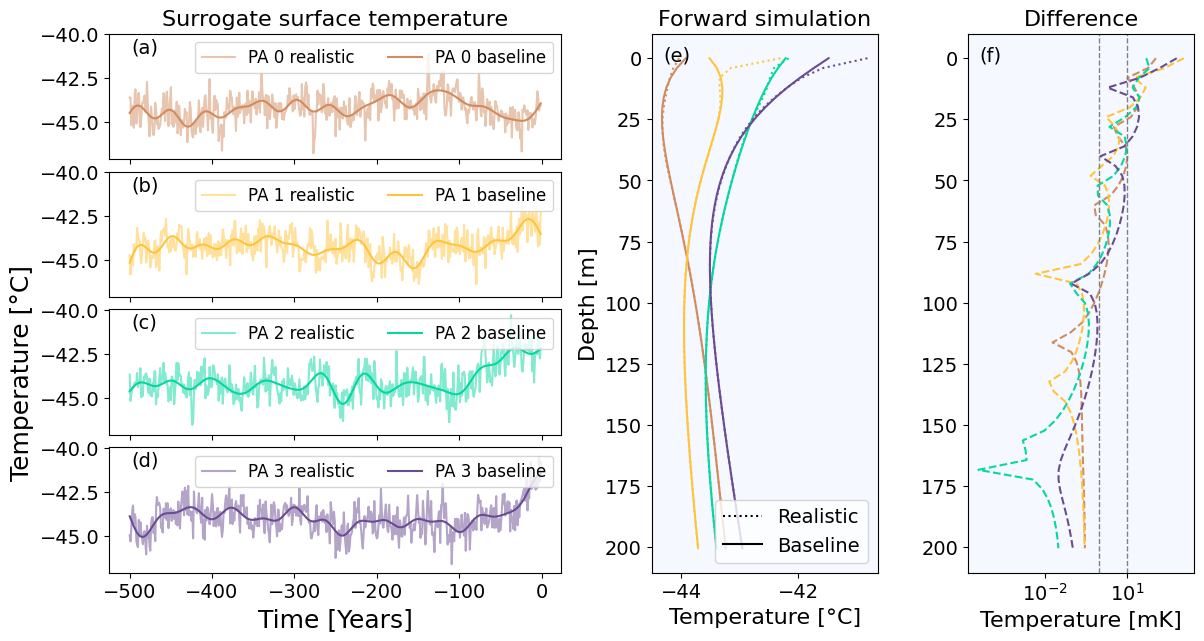

In [51]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
import numpy as np
from matplotlib.lines import Line2D

plt.rc('xtick', labelsize=14) 
plt.rc('ytick', labelsize=14)

fig = plt.figure(figsize=(14,7))

outer_gs = GridSpec(1, 3, width_ratios=[2,1,1], wspace=0.3)

# =========================
# LEFT PANEL (4 stacked signals)
# =========================
left_gs = GridSpecFromSubplotSpec(
    4, 1,
    subplot_spec=outer_gs[0],   # span first two columns
    hspace=0.1
)

# =========================
# RIGHT PANELS (side by side)
# =========================
ax_right1 = fig.add_subplot(outer_gs[1])
ax_right2 = fig.add_subplot(outer_gs[2])

# =========================
# DATA LISTS
# =========================
baseline_signals = [smooth_rsignal_1, smooth_rsignal_2, smooth_rsignal_3, smooth_rsignal_4]

signals = [rsignal_1, rsignal_2, rsignal_3, rsignal_4]

# labels = ['PA 0','PA 1','PA 2','PA 3']
labels_org = [
    'PA 0 realistic',
    'PA 1 realistic',
    'PA 2 realistic',
    'PA 3 realistic'
]
labels_fitted = [
    'PA 0 baseline',
    'PA 1 baseline',
    'PA 2 baseline',
    'PA 3 baseline'
]

colors  = ['#d08c60', '#ffc43d', '#06d6a0', '#6a4c93']
subplotlabels=['(a)','(b)','(c)','(d)','(e)','(f)']

left_axes=[]

# =========================
# LEFT SIGNAL PANELS
# =========================
for i in range(4):
    if i == 0:
        ax = fig.add_subplot(left_gs[i])
    else:
        ax = fig.add_subplot(
            left_gs[i],
            sharex=left_axes[0],
            sharey=left_axes[0]
        )

    # plot noisy signal
    ax.plot(
        all_fwds_40kic[i].times-500,
        signals[i],
        color=colors[i],
        label=labels_org[i],
        alpha=0.5
    )

    # plot fitted kernel
    ax.plot(
        all_fwds_smooth_40kic[i].times-500,
        baseline_signals[i],
        label=labels_fitted[i],
        color=colors[i]
    )

    ax.text(0.05,0.85,subplotlabels[i], transform=ax.transAxes, fontsize=14)
    ax.legend(loc='upper right', fontsize=12,ncol=3)
    left_axes.append(ax)
left_axes[0].set_title('Surrogate surface temperature', fontsize=16)
# Hide x-ticks for all but last left panel
for ax in left_axes[:-1]:
    plt.setp(ax.get_xticklabels(), visible=False)

left_axes[2].set_ylabel('Temperature [°C]', fontsize=18)
left_axes[-1].set_xlabel('Time [Years]', fontsize=18)

# =========================
# RIGHT PANEL 1
# =========================
for i in range(4):
    ax_right1.plot(
        all_fwds_smooth_40kic[i].T[:51,-1],
        all_fwds_smooth_40kic[i].depths[:51],
        color=colors[i],
        alpha=1, 
        label=labels_fitted[i]
    )
    ax_right1.plot(
        all_fwds_40kic[i].T[:51,-1],
        all_fwds_40kic[i].depths[:51],
        color=colors[i],
        alpha=1, 
        linestyle='dotted', 
        lw=1.5,
        label=labels_org[i]
    )
ax_right1.set_title('Forward simulation', fontsize=16)
ax_right1.invert_yaxis()
ax_right1.set_facecolor('#F5F9FF') 
custom_handles = [
    Line2D([0], [0], color='black', label='Realistic', markersize=8, linestyle='dotted',markerfacecolor='none'),
    Line2D([0], [0], color='black', label='Baseline', markersize=8, linestyle='-',markerfacecolor='none')
]

# Use these handles in the legend
ax_right1.legend(handles=custom_handles, fontsize=14, loc='lower right')

ax_right1.set_xlabel('Temperature [°C]', fontsize=16)
ax_right1.set_ylabel('Depth [m]', fontsize=16)
ax_right1.text(0.05,0.95, subplotlabels[4], transform=ax_right1.transAxes, fontsize=14)

# =========================
# RIGHT PANEL 2
# =========================
for i in range(4):
    ax_right2.plot(
        np.abs(all_fwds_40kic[i].T[:51,-1]-all_fwds_smooth_40kic[i].T[:51,-1])*1000,
        all_fwds_40kic[i].depths[:51],
        color=colors[i],
        linestyle='dashed',
        label=labels_org[i]
    )
ax_right2.set_title('Difference', fontsize=16)
ax_right2.invert_yaxis()
ax_right2.set_xlabel('Temperature [mK]', fontsize=16)
ax_right2.text(0.05,0.95, subplotlabels[5], transform=ax_right2.transAxes, fontsize=14)
ax_right2.axvline(x=1, color='gray', linestyle='--', linewidth=1)
ax_right2.axvline(x=10, color='gray', linestyle='--', linewidth=1)
# ax_right2.legend(loc='lower right', fontsize=11)
ax_right2.set_facecolor('#F5F9FF') 
ax_right2.set_xscale('log')
# plt.savefig('Figures/fig_case_study_signals.png', dpi=300)
plt.show()